<a href="https://colab.research.google.com/github/Aparna-981/ict-project/blob/main/exit_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Data Load

In [2]:
data=pd.read_excel('/content/partpdf_1772778618075_partpdf_1763620814447_airbnb.xlsx')
data.to_csv("AirBnB_NYC.csv",index=False)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
data

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
1,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
2,1039,2008-07-25,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0
3,1783,2008-08-12,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0
4,2078,2008-08-15,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30470,43022976,2015-08-31,10 Mins to Time Square/two floors,Queens,Apartment,NaN,Entire home/apt,11101.0,5.0,1,0,300,NaN
30471,42993382,2015-08-31,"1BR ocean view & F,Q train st",Brooklyn,Apartment,NaN,Private room,11224.0,2.0,1,0,125,NaN
30472,43033067,2015-08-31,Amazing Private Room,Brooklyn,Other,NaN,Private room,11206.0,1.0,1,0,80,NaN
30473,43000991,2015-08-31,Charming private female room: UWS,Manhattan,Apartment,NaN,Private room,10025.0,1.0,1,0,35,NaN


In [5]:
data.shape


(30475, 13)

In [6]:
data["Host_Since"]=pd.to_datetime(data['Host Since'], format='%d/%m/%Y', errors='coerce')
reference_date = pd.Timestamp('01-01-2025')
data['host_tenure_days'] = (reference_date - data['Host Since']).dt.days

create  a column name host_tenure_days.An more days can charge more because
guests trust them, they have better reviews, and they
optimize their listings for maximum profit

In [7]:
data

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,Host_Since,host_tenure_days
0,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN,2008-06-26,6033
1,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0,2008-06-26,6033
2,1039,2008-07-25,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0,2008-07-25,6004
3,1783,2008-08-12,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0,2008-08-12,5986
4,2078,2008-08-15,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0,2008-08-15,5983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30470,43022976,2015-08-31,10 Mins to Time Square/two floors,Queens,Apartment,NaN,Entire home/apt,11101.0,5.0,1,0,300,NaN,2015-08-31,3411
30471,42993382,2015-08-31,"1BR ocean view & F,Q train st",Brooklyn,Apartment,NaN,Private room,11224.0,2.0,1,0,125,NaN,2015-08-31,3411
30472,43033067,2015-08-31,Amazing Private Room,Brooklyn,Other,NaN,Private room,11206.0,1.0,1,0,80,NaN,2015-08-31,3411
30473,43000991,2015-08-31,Charming private female room: UWS,Manhattan,Apartment,NaN,Private room,10025.0,1.0,1,0,35,NaN,2015-08-31,3411


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30475 entries, 0 to 30474
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Host Id                     30475 non-null  int64         
 1   Host Since                  30475 non-null  datetime64[ns]
 2   Name                        30475 non-null  object        
 3   Neighbourhood               30475 non-null  object        
 4   Property Type               30472 non-null  object        
 5   Review Scores Rating (bin)  22155 non-null  float64       
 6   Room Type                   30475 non-null  object        
 7   Zipcode                     30341 non-null  float64       
 8   Beds                        30390 non-null  float64       
 9   Number of Records           30475 non-null  int64         
 10  Number Of Reviews           30475 non-null  int64         
 11  Price                       30475 non-null  int64     

In [9]:
data.duplicated().sum()

np.int64(17)

In [10]:
data.drop_duplicates()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,Host_Since,host_tenure_days
0,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN,2008-06-26,6033
1,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0,2008-06-26,6033
2,1039,2008-07-25,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0,2008-07-25,6004
3,1783,2008-08-12,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0,2008-08-12,5986
4,2078,2008-08-15,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0,2008-08-15,5983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30470,43022976,2015-08-31,10 Mins to Time Square/two floors,Queens,Apartment,NaN,Entire home/apt,11101.0,5.0,1,0,300,NaN,2015-08-31,3411
30471,42993382,2015-08-31,"1BR ocean view & F,Q train st",Brooklyn,Apartment,NaN,Private room,11224.0,2.0,1,0,125,NaN,2015-08-31,3411
30472,43033067,2015-08-31,Amazing Private Room,Brooklyn,Other,NaN,Private room,11206.0,1.0,1,0,80,NaN,2015-08-31,3411
30473,43000991,2015-08-31,Charming private female room: UWS,Manhattan,Apartment,NaN,Private room,10025.0,1.0,1,0,35,NaN,2015-08-31,3411


In [11]:
data.nunique()

,0
Host Id,24418
Host Since,2240
Name,29414
Neighbourhood,5
Property Type,19
Review Scores Rating (bin),15
Room Type,3
Zipcode,188
Beds,14
Number of Records,1


In [12]:
data.drop('Host Id', axis=1, inplace=True)

In [13]:
data.drop('Host Since',axis=1,inplace=True)

In [14]:
data.isnull().sum()

,0
Name,0
Neighbourhood,0
Property Type,3
Review Scores Rating (bin),8320
Room Type,0
Zipcode,134
Beds,85
Number of Records,0
Number Of Reviews,0
Price,0


the features such as Review Scores Rating ,Review Scores Rating,Beds,Zipcode,property Type have the null values

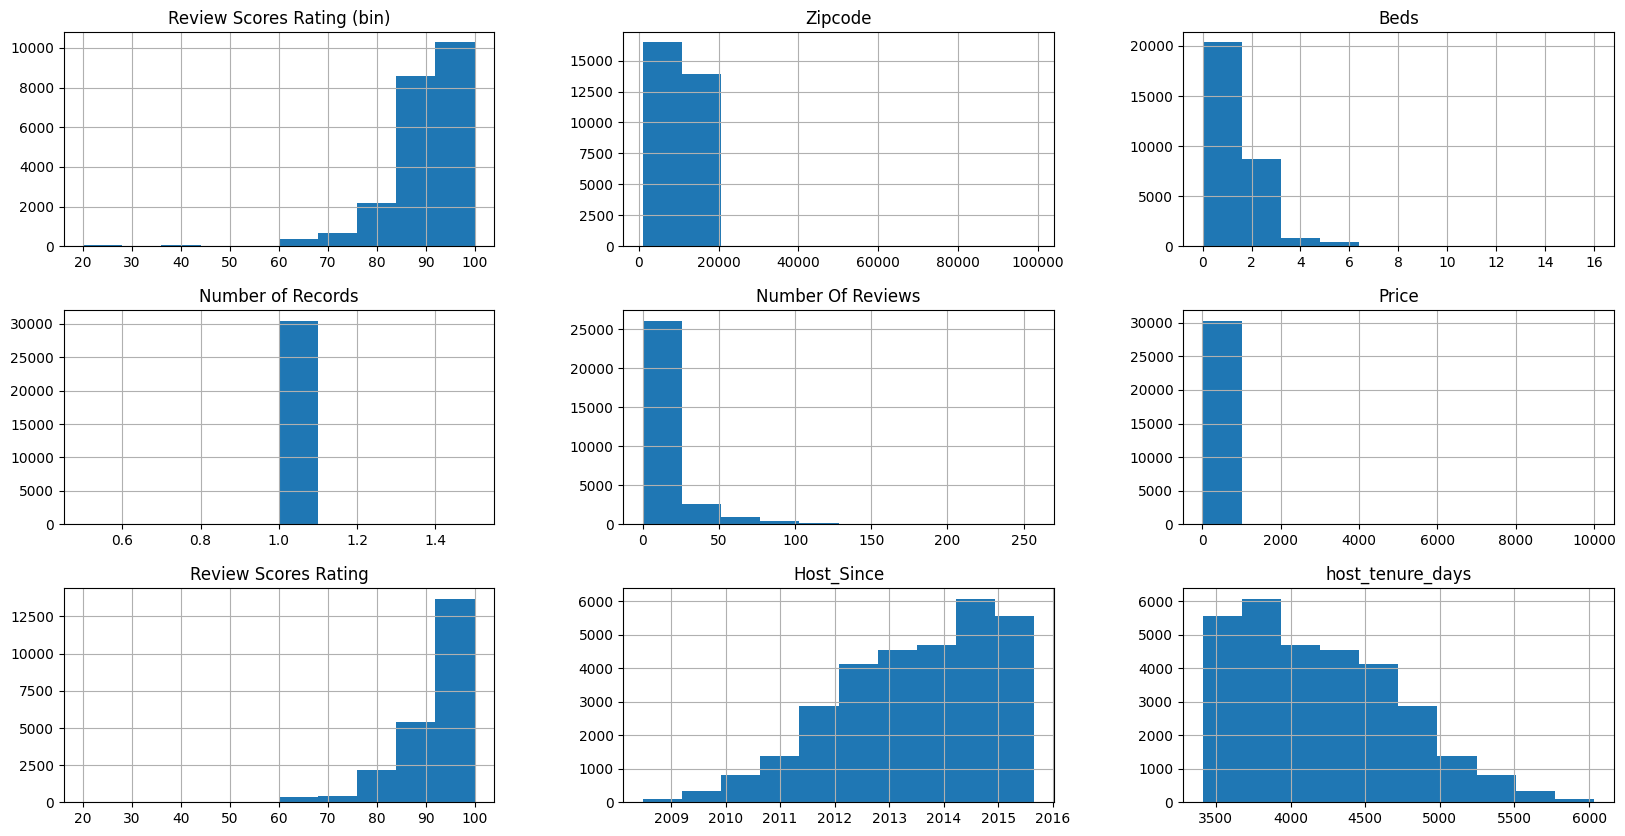

In [15]:
data.hist(figsize=(20,10))
data.plot

by using histogram we can choice mean/median can be used.Review Scores Rating ,Review Scores Rating,Beds,Zipcode in these column use median because they numerical values and mode is used in property type because they are catergorical values by using mode it replace the missing values by highest frequecy values

In [16]:
data['Review Scores Rating'] = data['Review Scores Rating'].fillna(data['Review Scores Rating'].median())
data['Review Scores Rating (bin)'] = data['Review Scores Rating (bin)'].fillna(data['Review Scores Rating (bin)'].median())
data['Beds'] = data['Beds'].fillna(data['Beds'].median())
data['Zipcode'] = data['Zipcode'].fillna(data['Zipcode'].median())

In [17]:
data['Property Type'] = data['Property Type'].fillna(data['Property Type'].mode()[0])

In [18]:
data.isnull().sum()

,0
Name,0
Neighbourhood,0
Property Type,0
Review Scores Rating (bin),0
Room Type,0
Zipcode,0
Beds,0
Number of Records,0
Number Of Reviews,0
Price,0


In [19]:
data.drop('Host_Since',axis=1,inplace=True)

Outliers handling

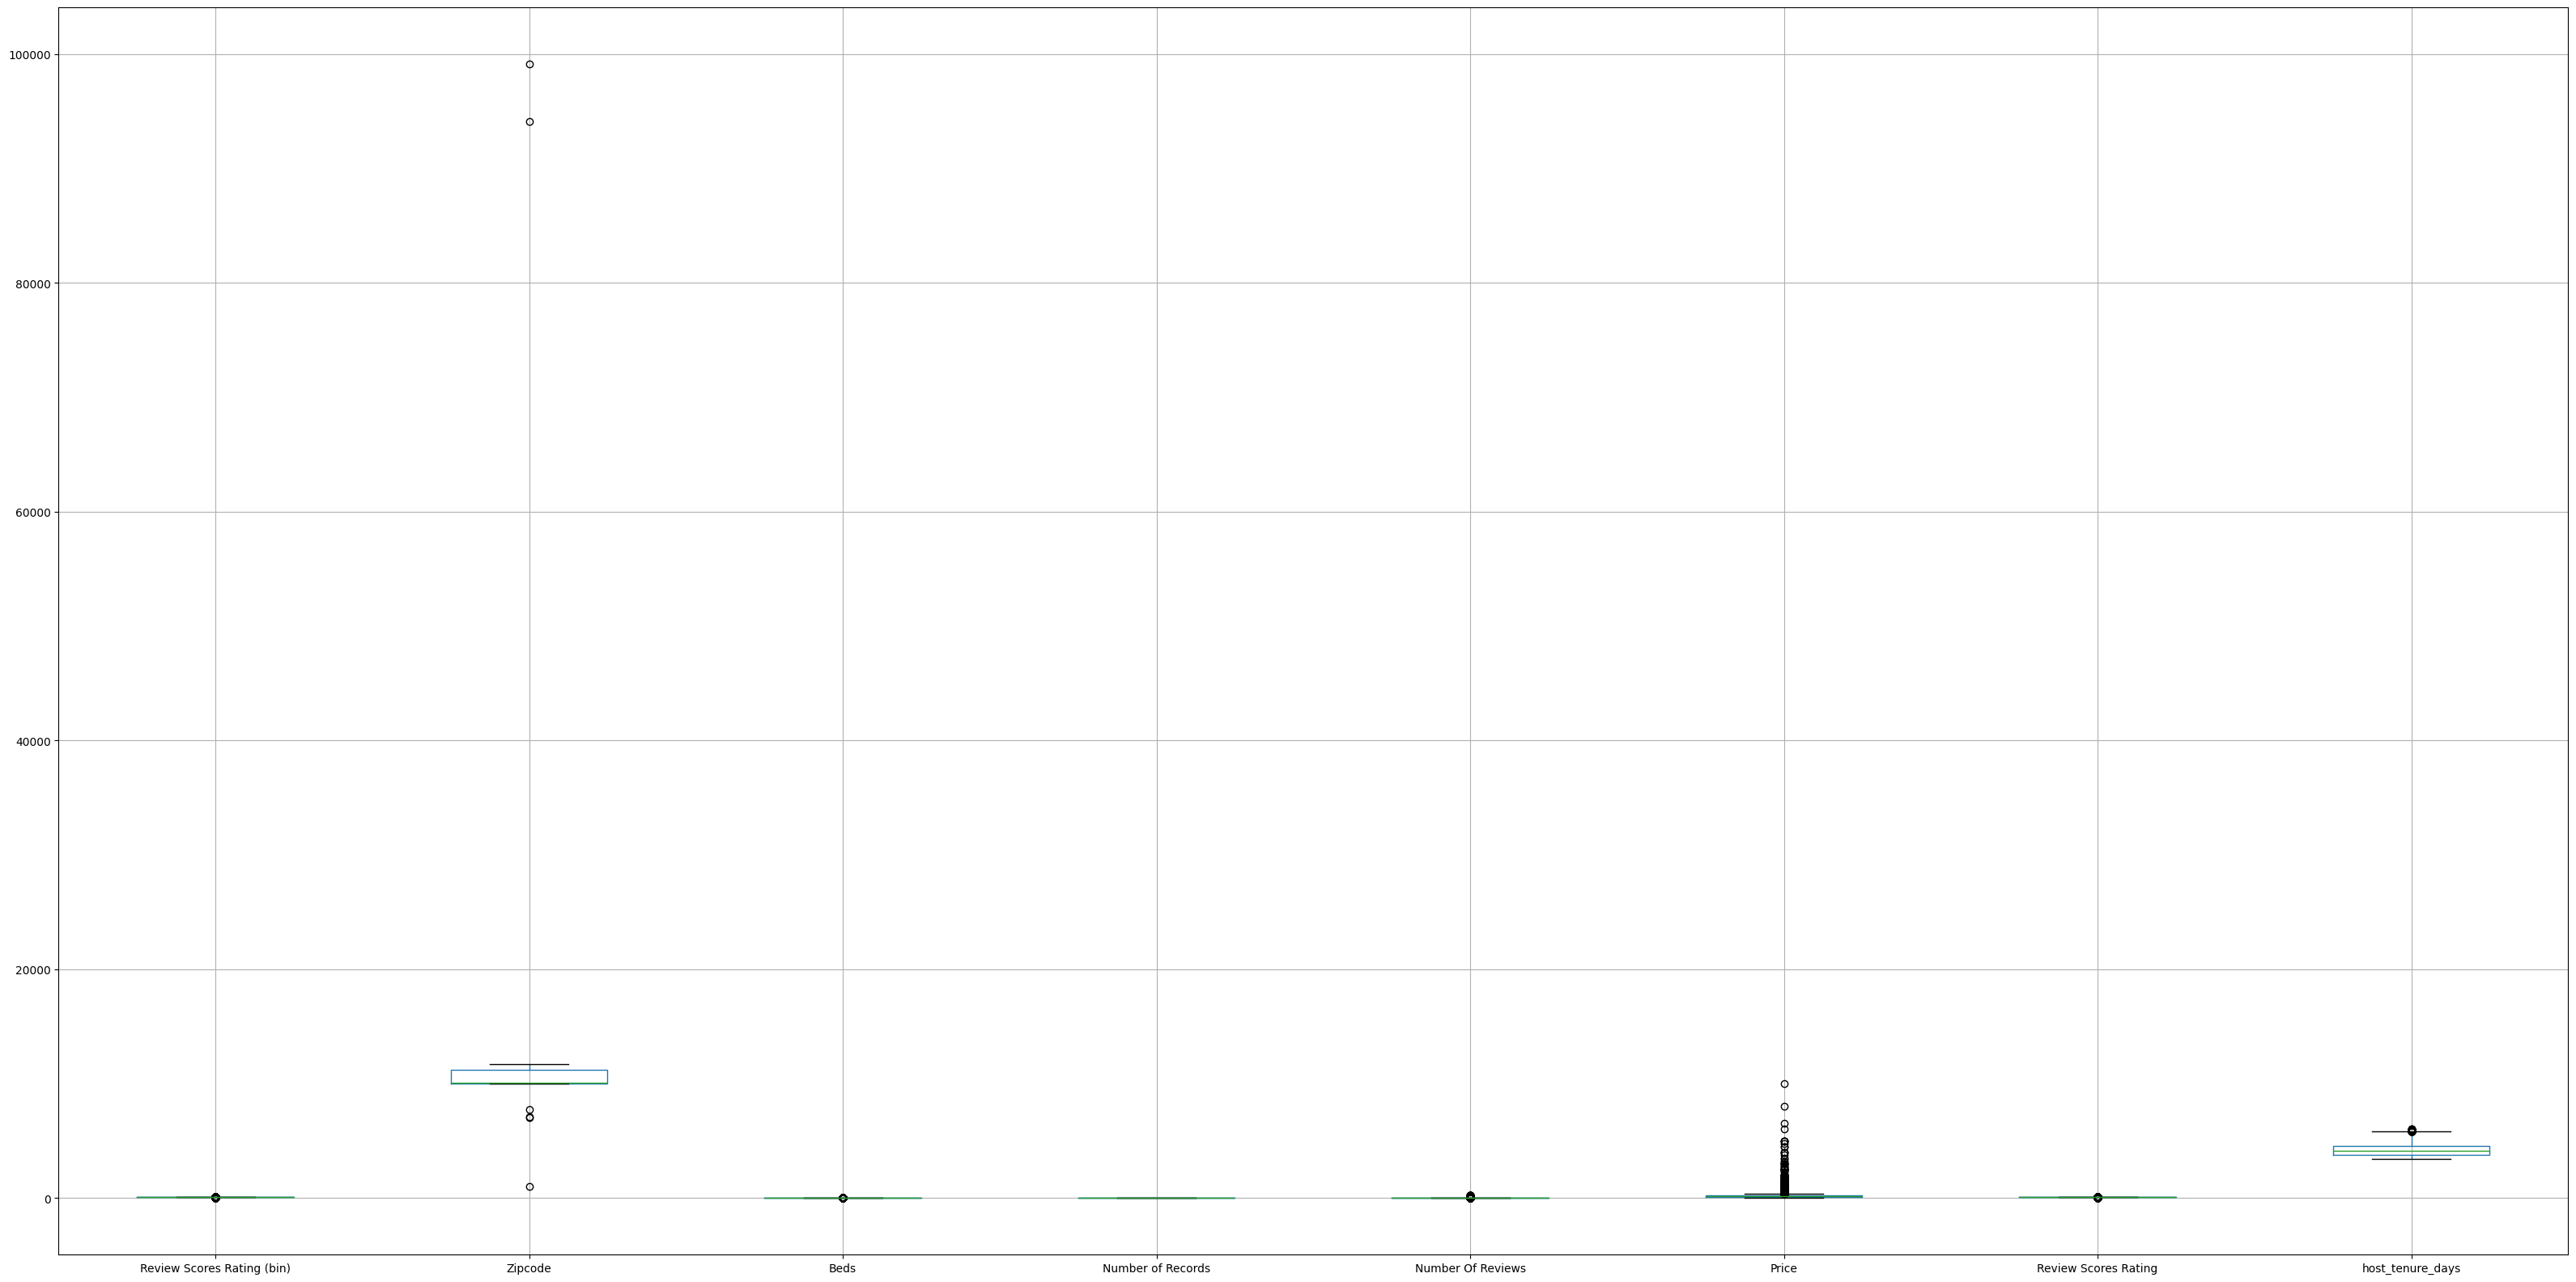

In [20]:
data.select_dtypes(include=['number']).boxplot(figsize=(40, 20))
plt.show()

In [21]:
data

,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,host_tenure_days
0,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,90.0,Entire home/apt,10024.0,3.0,1,0,199,94.0,6033
1,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0,6033
2,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0,6004
3,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0,5986
4,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0,5983
...,...,...,...,...,...,...,...,...,...,...,...,...
30470,10 Mins to Time Square/two floors,Queens,Apartment,90.0,Entire home/apt,11101.0,5.0,1,0,300,94.0,3411
30471,"1BR ocean view & F,Q train st",Brooklyn,Apartment,90.0,Private room,11224.0,2.0,1,0,125,94.0,3411
30472,Amazing Private Room,Brooklyn,Other,90.0,Private room,11206.0,1.0,1,0,80,94.0,3411
30473,Charming private female room: UWS,Manhattan,Apartment,90.0,Private room,10025.0,1.0,1,0,35,94.0,3411


new data set created with neighbourhood_room_interaction

In [22]:
data_new=data

In [23]:
data_new['neighbourhood_room_interaction'] = (
    data['Neighbourhood '].astype(str) + '_' +
    data['Room Type'].astype(str)
)

Encoding

with out new features

In [24]:
data_encoded = pd.get_dummies(data, columns=['Name',	'Neighbourhood ','Property Type',	'Room Type',	'neighbourhood_room_interaction'], drop_first=True,dtype=int)

In [25]:
data_encoded.columns

Index(['Review Scores Rating (bin)', 'Zipcode', 'Beds', 'Number of Records',
       'Number Of Reviews', 'Price', 'Review Scores Rating',
       'host_tenure_days', 'Name_     NYC, Manhattan, NY, UES B COZY',
       'Name_  3 bedroom DUPLEX, great location!',
       ...
       'neighbourhood_room_interaction_Brooklyn_Shared room',
       'neighbourhood_room_interaction_Manhattan_Entire home/apt',
       'neighbourhood_room_interaction_Manhattan_Private room',
       'neighbourhood_room_interaction_Manhattan_Shared room',
       'neighbourhood_room_interaction_Queens_Entire home/apt',
       'neighbourhood_room_interaction_Queens_Private room',
       'neighbourhood_room_interaction_Queens_Shared room',
       'neighbourhood_room_interaction_Staten Island_Entire home/apt',
       'neighbourhood_room_interaction_Staten Island_Private room',
       'neighbourhood_room_interaction_Staten Island_Shared room'],
      dtype='object', length=29459)

In [ ]:
import numpy as np

corr_matrix = data_encoded.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.9

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

data_encoded = data_encoded.drop(columns=to_drop)

print("Dropped columns:", to_drop)

In [ ]:
from sklearn.preprocessing import StandardScaler
sl=StandardScaler()
data_scaled=sl.fit_transform(data_encoded)
data_scaled=pd.DataFrame(data_scaled,columns=data_encoded.columns)
data_scaled

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
X=data_scaled.drop('Price',axis=1)
y=data_scaled['Price']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import pickle
RFR=RandomForestRegressor(n_estimators=100,random_state=42)

In [ ]:
Y_pred=RFR.predict(X_test)
r2=r2_score(y_test,Y_pred)
mae=mean_absolute_error(y_test,Y_pred)
mse=mean_squared_error(y_test,Y_pred)
rmse = np.sqrt(mse)

print("R2 Score:",r2)
print("MSE:",mse)
print("MAE:",mae)
print("RMSE:", rmse)

In [ ]:
pickle.dump(RFR,open("Model_RFR.pkl","wb"))
pickle.dump(sl,open("scaler_RFR.pkl","wb"))

with featuues